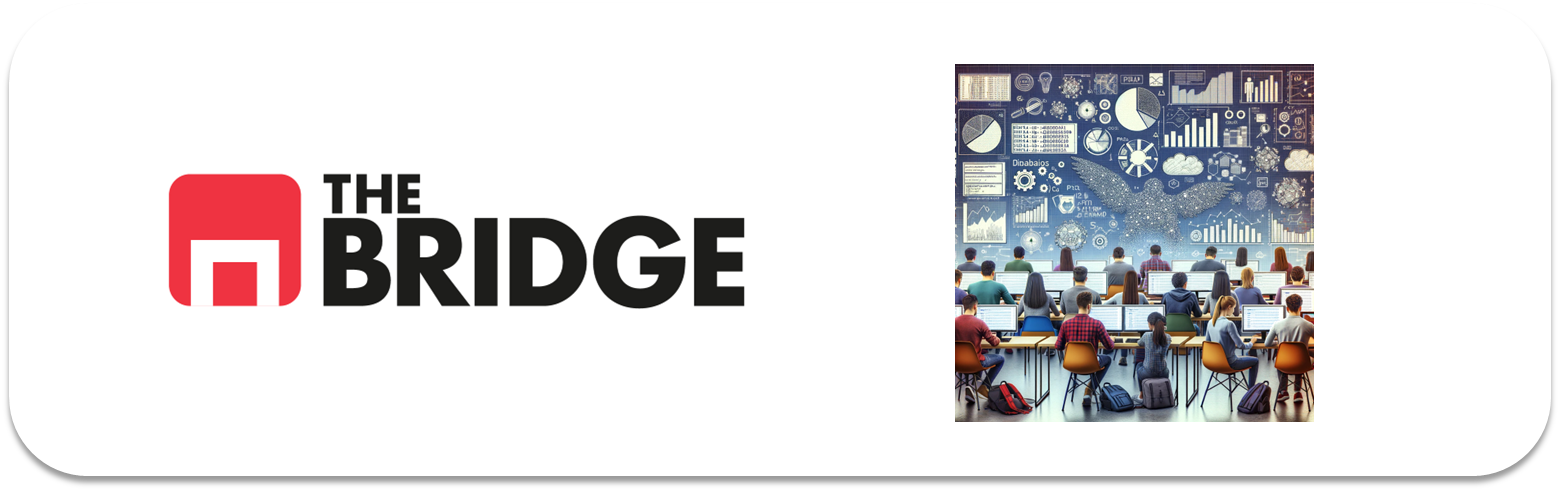

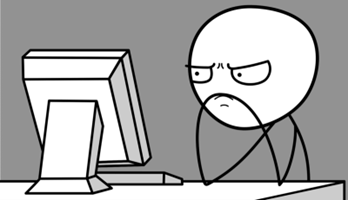

Para ejercitarte y afianzar lo aprendido sobre **Proceso de Datos**, como primera etapa de ML, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

### Ejercicio 1

Carga el dataset de advertising que encontrarás en la carpeta de datos. Muestra su información general. ¿Qué te llama la atención? ¿Tendremos que limpiar alguna variable?

In [35]:
df = pd.read_csv("./data/advertising_ml.csv")

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   str    
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(2), str(5)
memory usage: 78.3 KB


In [37]:
df.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35 years,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31 years,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26 years,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29 years,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35 años,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [38]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [39]:
df["Timestamp"].value_counts()

Timestamp
2016-03-27 00:53:11    1
2016-04-04 01:39:02    1
2016-03-13 20:35:42    1
2016-01-10 02:31:19    1
2016-06-03 03:36:18    1
                      ..
2016-02-11 21:49:00    1
2016-04-22 02:07:01    1
2016-02-01 17:24:57    1
2016-03-24 02:35:54    1
2016-06-03 21:43:21    1
Name: count, Length: 1000, dtype: int64

In [40]:
df["Age"].value_counts()

Age
31 years    34
28 years    30
29 years    28
31 años     26
36 años     26
            ..
56 años      2
59 años      1
61 years     1
58 años      1
59 years     1
Name: count, Length: 83, dtype: int64

In [41]:
df["Age"] = df["Age"].str.extract(r"(\d+)").astype(int)

In [42]:
df.Male.value_counts()

Male
0    519
1    481
Name: count, dtype: int64

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Daily Time Spent on Site  1000 non-null   float64       
 1   Age                       1000 non-null   int64         
 2   Area Income               1000 non-null   float64       
 3   Daily Internet Usage      1000 non-null   float64       
 4   Ad Topic Line             1000 non-null   str           
 5   City                      1000 non-null   str           
 6   Male                      1000 non-null   int64         
 7   Country                   1000 non-null   str           
 8   Timestamp                 1000 non-null   datetime64[us]
 9   Clicked on Ad             1000 non-null   int64         
dtypes: datetime64[us](1), float64(3), int64(3), str(3)
memory usage: 78.3 KB


### Ejercicio 2

Tenemos que entender el problema antes de seguir. Nos dicen que la compañía "QuickRespond" quiere poder generar un modelo que a partir de datos como los del dataset para poder dirigir mejor su campaña de anuncios. Hablando con ellos llegamos a la conclusión de que queremos un modelo para poder predecir si un usuario pulsará en el link de un anuncio o no. ¿Qué tipo de problemas estamos tratando?¿Y de que tipo de aprendizaje?¿Existe una variable target que puedas identificar rapidamente?

Estamos tratando un problema de Clasificación, con aprendizaje supervisado. 

La variable target identificada es `Clicked on Ad`.

### Ejercicio 3

Volvamos ya a los datos. Intenta dar una definicón de cada columna, obten su cardinalidad y en función de esta y del tipo de variable de pandas, clasifícalas en categóricas y numéricas.

In [44]:
cardinalidades = []
for col in df.columns:
    cardinalidad = df[col].nunique() / len(df)
    cardinalidades.append(cardinalidad*100)
    print(f"La cardinalidad de la variable {col} es de {round(cardinalidad*100, 2)}%")

La cardinalidad de la variable Daily Time Spent on Site es de 90.0%
La cardinalidad de la variable Age es de 4.3%
La cardinalidad de la variable Area Income es de 100.0%
La cardinalidad de la variable Daily Internet Usage es de 96.6%
La cardinalidad de la variable Ad Topic Line es de 100.0%
La cardinalidad de la variable City es de 96.9%
La cardinalidad de la variable Male es de 0.2%
La cardinalidad de la variable Country es de 23.7%
La cardinalidad de la variable Timestamp es de 100.0%
La cardinalidad de la variable Clicked on Ad es de 0.2%


In [45]:
df_descripciones = pd.DataFrame(index=df.columns.T)

In [46]:
df_descripciones["Description"] = ["Tiempo en la web",
                    "Edad usuario",
                    "Ingresos medios del Area de Residencia",
                    "Uso diario de Internet",
                    "Tema del anuncio mostrado",
                    "Ciudad del usuario",
                    "Es hombre (0 = False, 1 = True)",
                    "País del usuario",
                    "Fecha visualización del anuncio",
                    "Click en link del anuncio (0 = False, 1 = True)"
                    ]

In [47]:
df_descripciones["Cardinalidad"] = cardinalidades

In [48]:
df_descripciones

,Description,Cardinalidad
Daily Time Spent on Site,Tiempo en la web,90.0
Age,Edad usuario,4.3
Area Income,Ingresos medios del Area de Residencia,100.0
Daily Internet Usage,Uso diario de Internet,96.6
Ad Topic Line,Tema del anuncio mostrado,100.0
City,Ciudad del usuario,96.9
Male,"Es hombre (0 = False, 1 = True)",0.2
Country,País del usuario,23.7
Timestamp,Fecha visualización del anuncio,100.0
Clicked on Ad,"Click en link del anuncio (0 = False, 1 = True)",0.2


In [49]:
df_descripciones["Clasification"] = ["Numérica continua",
                                     "Numérica discreta",
                                     "Numérica continua",
                                     "Numérica continua",
                                     "Categórica nominal",
                                     "Categórica nominal",
                                     "Categórica binaria",
                                     "Categórica nominal",
                                     "Datetime",
                                     "Categórica binaria"]

In [50]:
df_descripciones

,Description,Cardinalidad,Clasification
Daily Time Spent on Site,Tiempo en la web,90.0,Numérica continua
Age,Edad usuario,4.3,Numérica discreta
Area Income,Ingresos medios del Area de Residencia,100.0,Numérica continua
Daily Internet Usage,Uso diario de Internet,96.6,Numérica continua
Ad Topic Line,Tema del anuncio mostrado,100.0,Categórica nominal
City,Ciudad del usuario,96.9,Categórica nominal
Male,"Es hombre (0 = False, 1 = True)",0.2,Categórica binaria
Country,País del usuario,23.7,Categórica nominal
Timestamp,Fecha visualización del anuncio,100.0,Datetime
Clicked on Ad,"Click en link del anuncio (0 = False, 1 = True)",0.2,Categórica binaria


### Ejercicio 4

Limpia las columnas que necesiten ser limpiadas, no completes nulos (porque asignar valores a nulos sólo puedes hacerlo primero con el train, ya explicaremos con detalle por qué). 

In [51]:
# HECHO

### Ejercicio 5

Divide el datset en train y test, empleando sklearn para ello tal y como hemos hecho en el workout. Usa la regla del 80-20

In [54]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=44)

### Ejercicio 6

Haz un pequeño análisis univariante de las columnas numéricas (muestra sus histogramas)

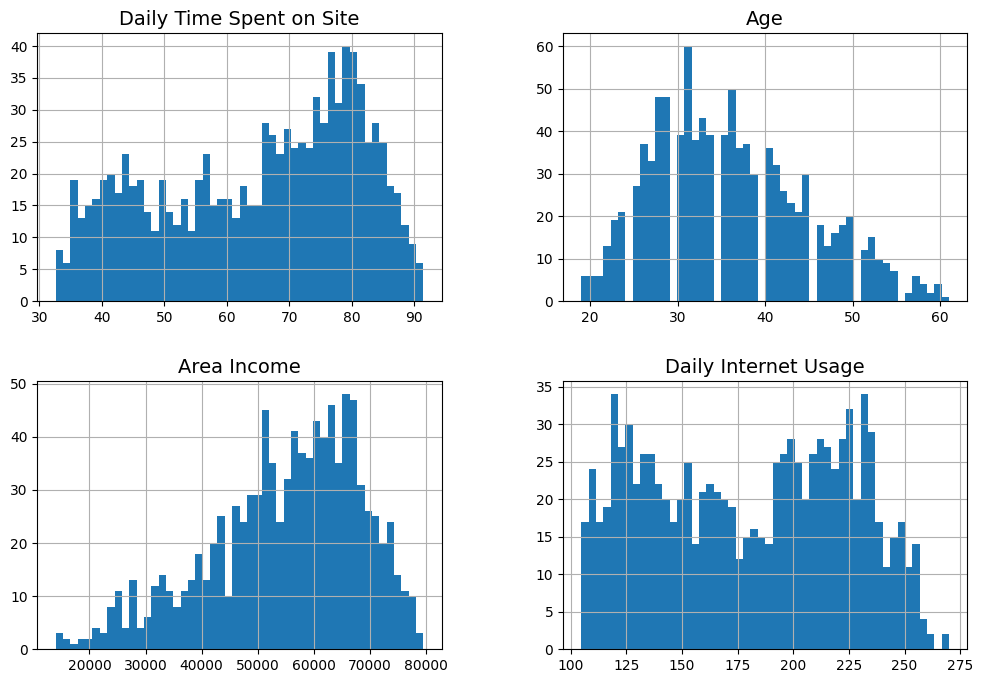

In [ ]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

cols_num = ["Daily Time Spent on Site",
             "Age",
             "Area Income",
             "Daily Internet Usage"]

df[cols_num].hist(bins=50, figsize=(12, 8))
plt.show()

### Ejercicio 7

Muestra las correlaciones de las variables continuas con un "PairPlot" y emplea como codigo de color la variable target. [Esto es otra forma de hacer un bivariante y un multivariante a la vez]. Para ello como argumento del pairplot de seaborn usa el dataframe de train (no la matriz de correlación)

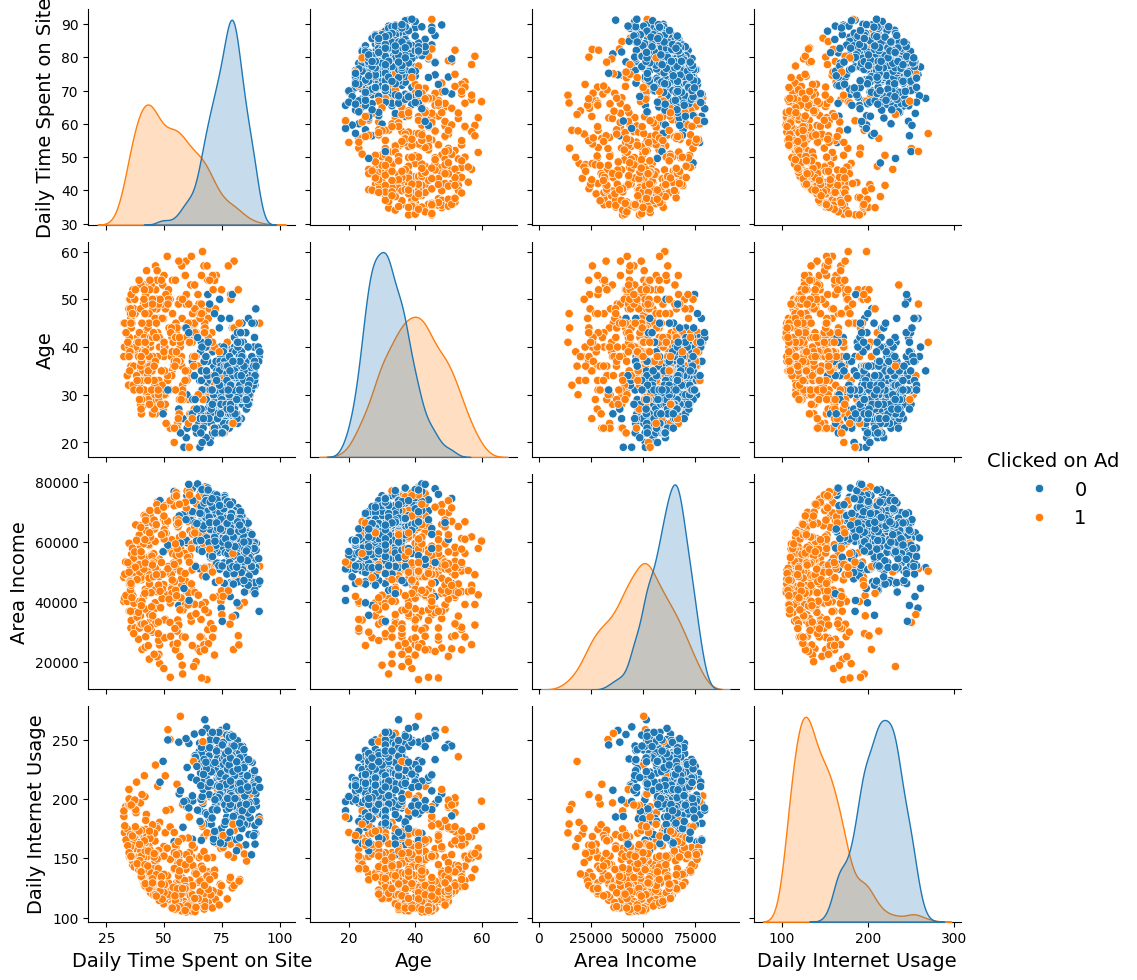

In [61]:
cols = [
    "Daily Time Spent on Site",
    "Age",
    "Area Income",
    "Daily Internet Usage",
    "Clicked on Ad"
]

sns.pairplot(train_set[cols], hue="Clicked on Ad")

### Ejercicio 8

Fijándote en la diagonal principal del gráfico anterior haz una selecció de features:

In [68]:
features = [col for col in cols if col != "Clicked on Ad"]

target = ["Clicked on Ad"]